# Experiment Visualization from Training Logs

**This notebook is used for visualizing the experiments of UltraGCN, we have colllected the training logs (in .txt format) in all of the ipynbs inside the experiment folder with the same format structure and plotting necessary metrics into graph for better visualization**

**Read Log**

In [4]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os

**We write a plotting function to visualize the 2 important metrics: Recall and NDCG as well as visualizing the system metrics performance base on the Log Pattern**

**Example Log Sample**

**EPOCH[0/2000] loss:49.226 | F1:0.0028 | P:0.0015 | R:0.0295 | NDCG:0.0124 | T:21.94s | RAM:2519.7MB | CPU:15.3% | VRAM:23.7MB**

**We utilize the re library to get extract the recall, ndcg, ram and vram metrics**


In [5]:
def plot_metrics_from_log(log_path: str) -> str:
    recall_vals = []
    ndcg_vals = []
    ram_vals = []
    vram_vals = []
    losses = []
    epochs = []

    title_prefix = os.path.splitext(os.path.basename(log_path))[0] + ' run'

    pattern = re.compile(
        r"EPOCH\[(\d+)/\d+\]"
        r".*?loss:(\d+\.\d+)"
        r".*?R:(\d+\.\d+)"
        r".*?NDCG:(\d+\.\d+)"
        r".*?RAM:(\d+\.\d+)MB"
        r".*?VRAM:(\d+\.\d+)MB"
    )

    with open(log_path, 'r', encoding='utf-8') as fin:
        for line in fin:
            match = pattern.search(line)
            if match:
                epoch = int(match.group(1))
                loss = float(match.group(2))
                recall = float(match.group(3))
                ndcg = float(match.group(4))
                ram = float(match.group(5))
                vram = float(match.group(6))

                epochs.append(epoch)
                losses.append(loss)
                recall_vals.append(recall)
                ndcg_vals.append(ndcg)
                ram_vals.append(ram)
                vram_vals.append(vram)

    # ===== Best metrics =====
    best_recall_idx = np.argmax(recall_vals)
    best_ndcg_idx = np.argmax(ndcg_vals)

    print(f"Best Recall : {recall_vals[best_recall_idx]:.6f} @ epoch {epochs[best_recall_idx]}")
    print(f"Best NDCG   : {ndcg_vals[best_ndcg_idx]:.6f} @ epoch {epochs[best_ndcg_idx]}")

    avg_ram = np.mean(ram_vals)
    avg_vram = np.mean(vram_vals)
    print(f'Average System RAM : {avg_ram:.2f} MB')
    print(f'Average System VRAM: {avg_vram:.2f} MB')

    # ===== Plot =====
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    # (1) Loss
    axs[0].plot(epochs, losses, color = 'green')
    axs[0].set_title(f"{title_prefix} - Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")

    # (2) Recall + NDCG chung
    axs[1].plot(epochs, recall_vals, label="Recall")
    axs[1].plot(epochs, ndcg_vals, label="NDCG")
    axs[1].scatter(epochs[best_recall_idx], recall_vals[best_recall_idx])
    axs[1].scatter(epochs[best_ndcg_idx], ndcg_vals[best_ndcg_idx])
    axs[1].set_title(f"{title_prefix} - Recall & NDCG")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Score")
    axs[1].legend()

    # (3) RAM
    axs[2].plot(epochs, ram_vals, color="blue")
    axs[2].set_title(f"{title_prefix} - RAM Usage")
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("RAM (MB)")

    # (4) VRAM
    axs[3].plot(epochs, vram_vals, color="blue")
    axs[3].set_title(f"{title_prefix} - VRAM Usage")
    axs[3].set_xlabel("Epoch")
    axs[3].set_ylabel("VRAM (MB)")

    plt.tight_layout()
    plt.show()

**Yelp2018**

Best Recall : 0.067400 @ epoch 62
Best NDCG   : 0.055600 @ epoch 62
Average System RAM : 6906.99 MB
Average System VRAM: 83.19 MB


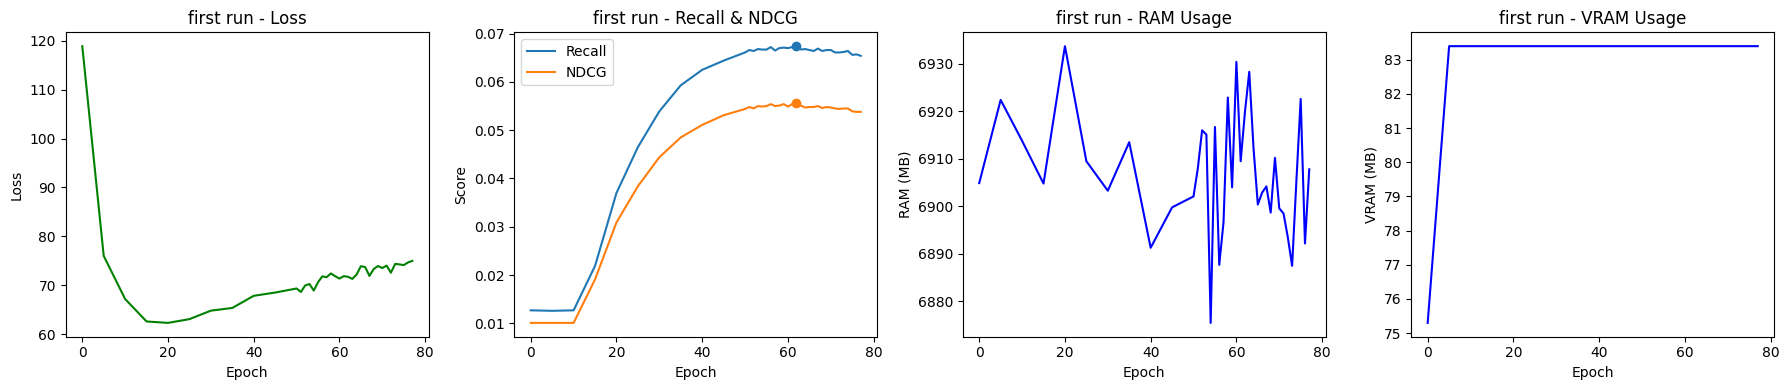

In [6]:
plot_metrics_from_log("yelp2018/first.txt")

Best Recall : 0.067700 @ epoch 58
Best NDCG   : 0.055600 @ epoch 58
Average System RAM : 7367.44 MB
Average System VRAM: 83.16 MB


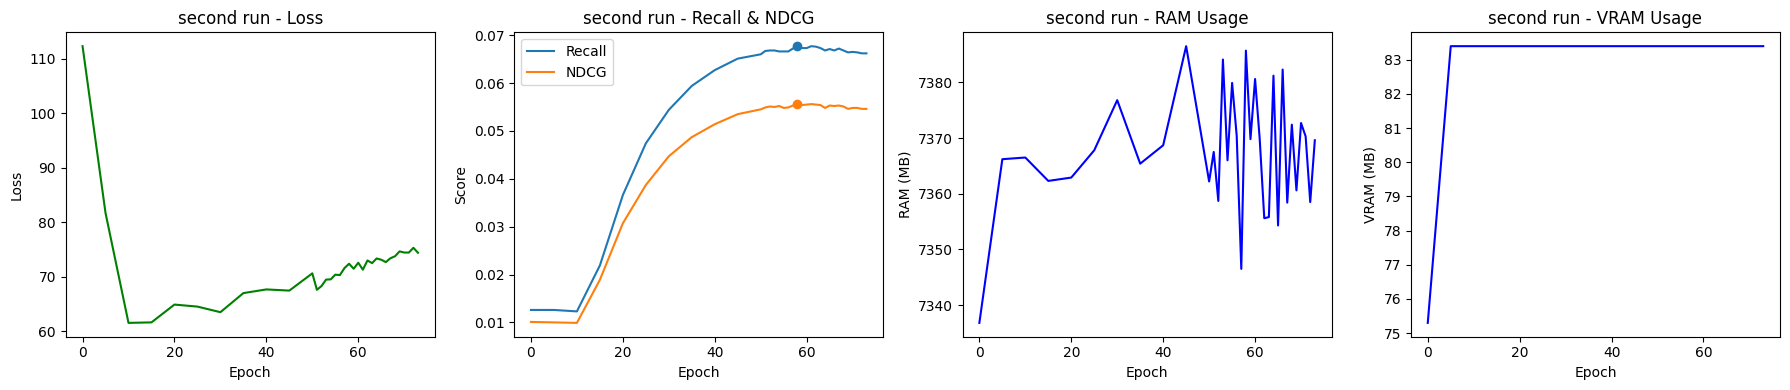

In [7]:
plot_metrics_from_log("yelp2018/second.txt")

Best Recall : 0.067400 @ epoch 60
Best NDCG   : 0.055400 @ epoch 60
Average System RAM : 7402.76 MB
Average System VRAM: 83.18 MB


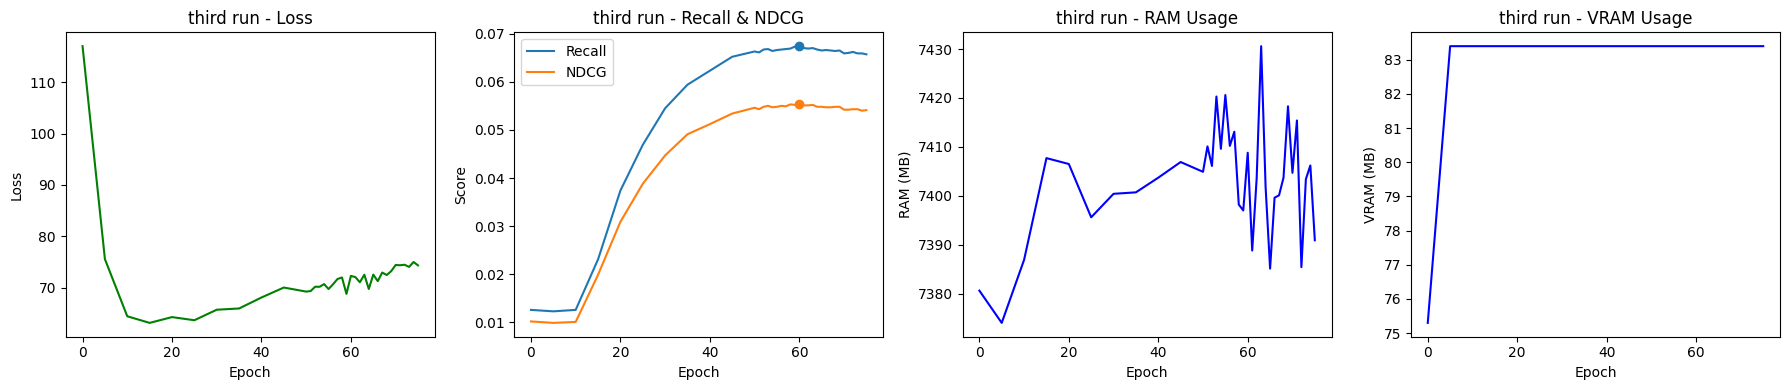

In [8]:
plot_metrics_from_log("yelp2018/third.txt")

**AmazonBook**

Best Recall : 0.067800 @ epoch 76
Best NDCG   : 0.055400 @ epoch 84
Average System RAM : 21106.93 MB
Average System VRAM: 163.54 MB


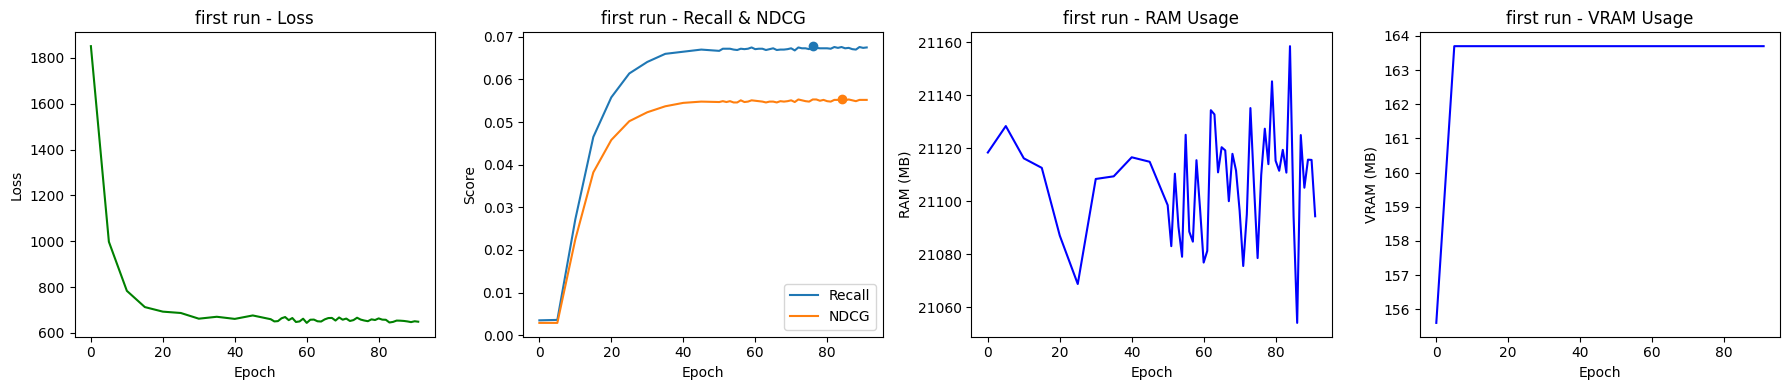

In [9]:
plot_metrics_from_log("amazonbook/first.txt")

Best Recall : 0.067700 @ epoch 65
Best NDCG   : 0.055200 @ epoch 65
Average System RAM : 21154.75 MB
Average System VRAM: 163.50 MB


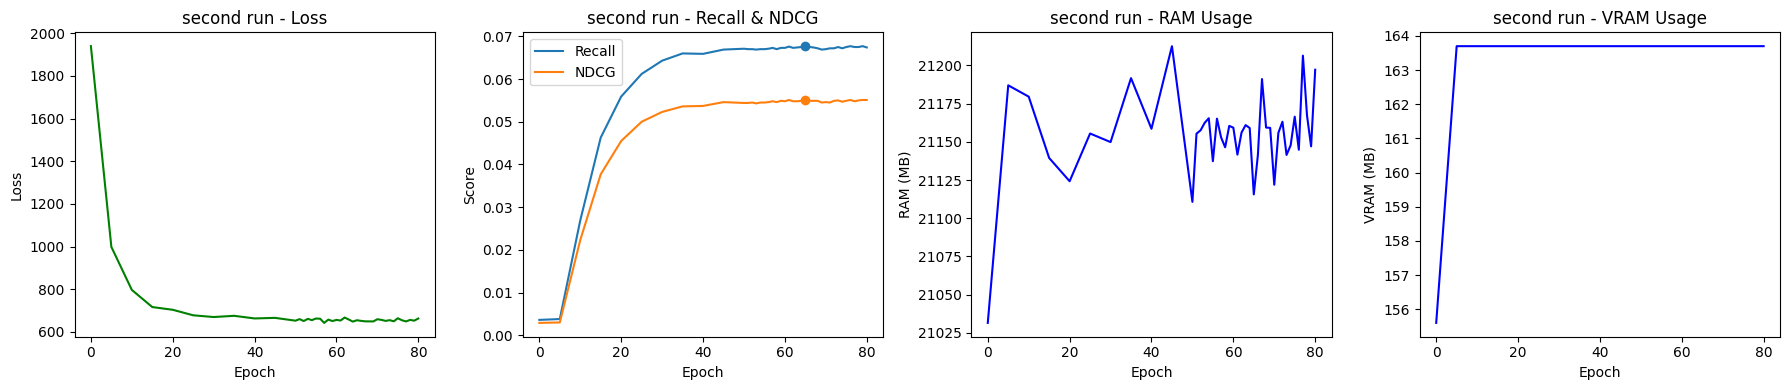

In [10]:
plot_metrics_from_log("amazonbook/second.txt")

Best Recall : 0.068300 @ epoch 110
Best NDCG   : 0.055600 @ epoch 116
Average System RAM : 21039.14 MB
Average System VRAM: 163.61 MB


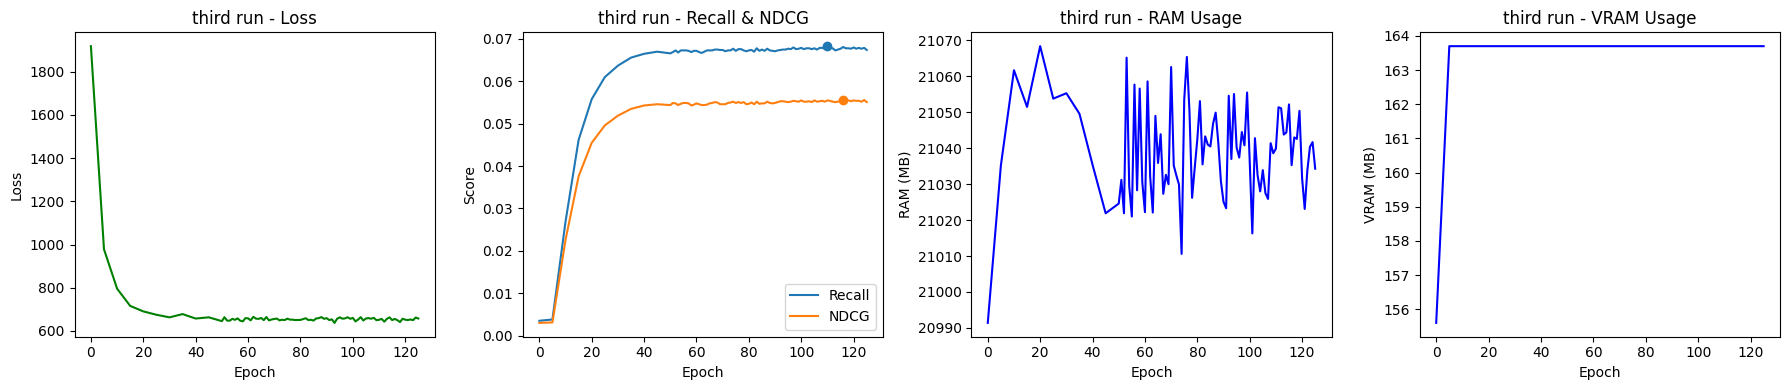

In [11]:
plot_metrics_from_log("amazonbook/third.txt")

**Gowalla**

Best Recall : 0.186600 @ epoch 649
Best NDCG   : 0.158400 @ epoch 680
Average System RAM : 6930.11 MB
Average System VRAM: 84.99 MB


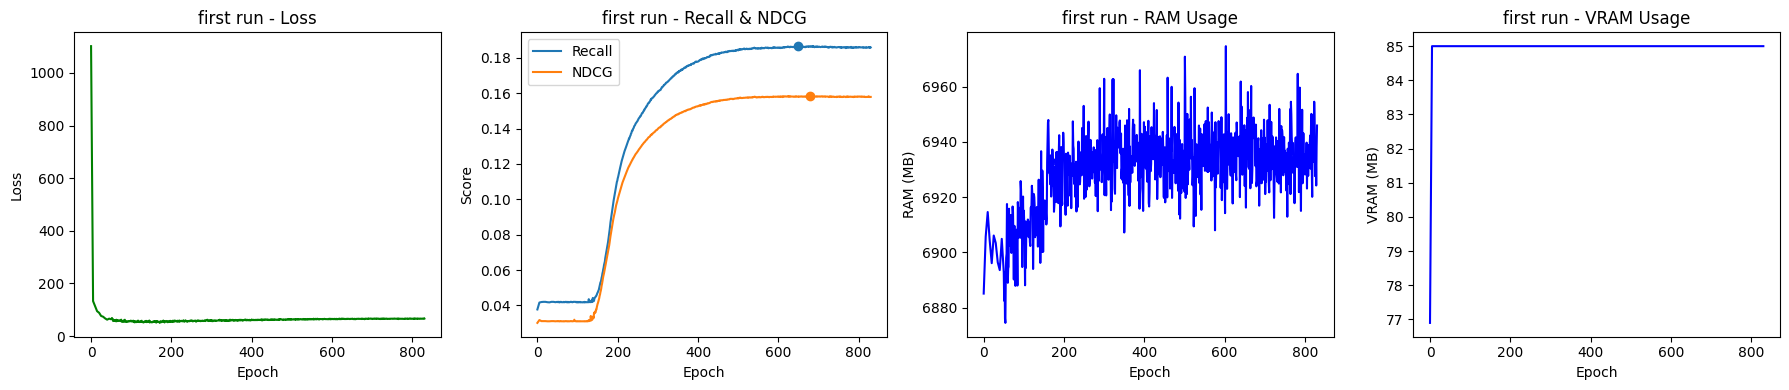

In [12]:
plot_metrics_from_log("gowalla/first.txt")

Best Recall : 0.185800 @ epoch 727
Best NDCG   : 0.158100 @ epoch 693
Average System RAM : 6732.12 MB
Average System VRAM: 84.99 MB


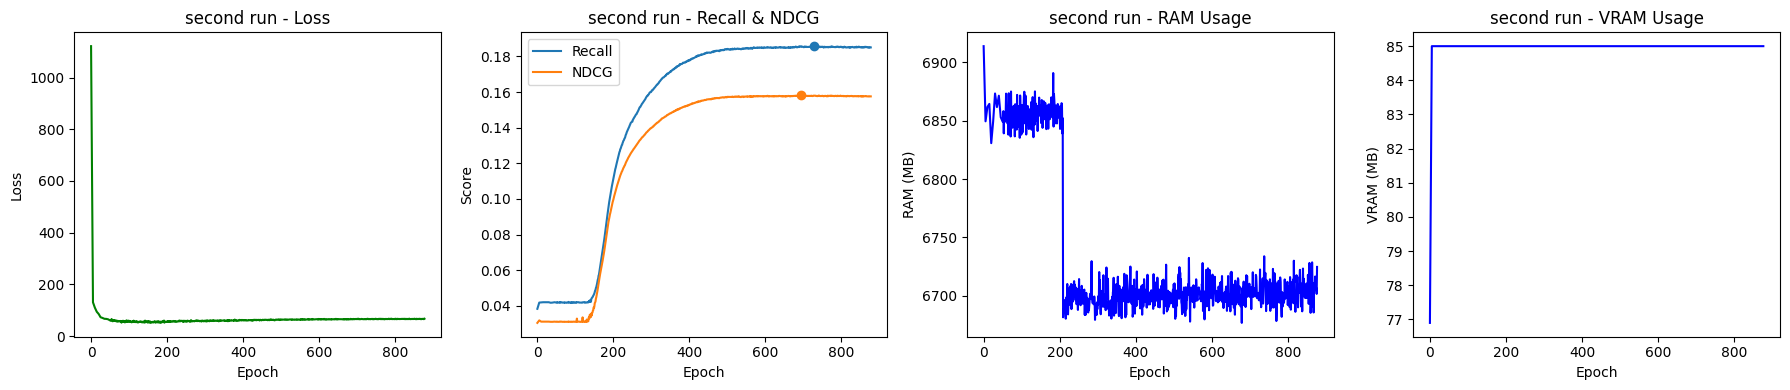

In [13]:
plot_metrics_from_log("gowalla/second.txt")

Best Recall : 0.185700 @ epoch 743
Best NDCG   : 0.157700 @ epoch 656
Average System RAM : 6984.48 MB
Average System VRAM: 84.99 MB


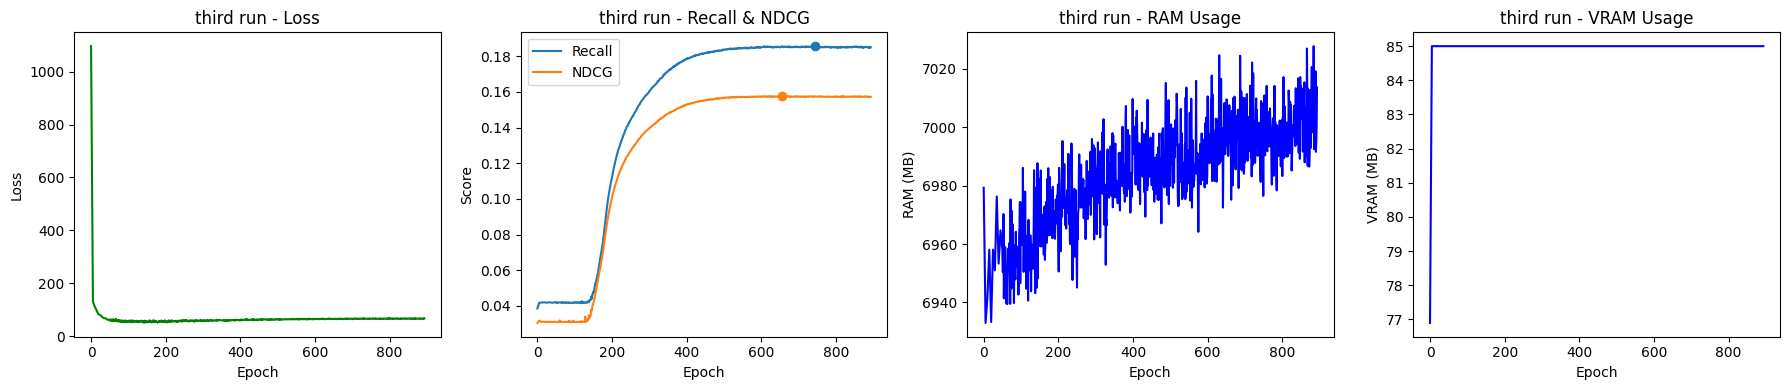

In [14]:
plot_metrics_from_log("gowalla/third.txt")

**Movielen**

Best Recall : 0.278300 @ epoch 85
Best NDCG   : 0.263800 @ epoch 85
Average System RAM : 2254.44 MB
Average System VRAM: 27.92 MB


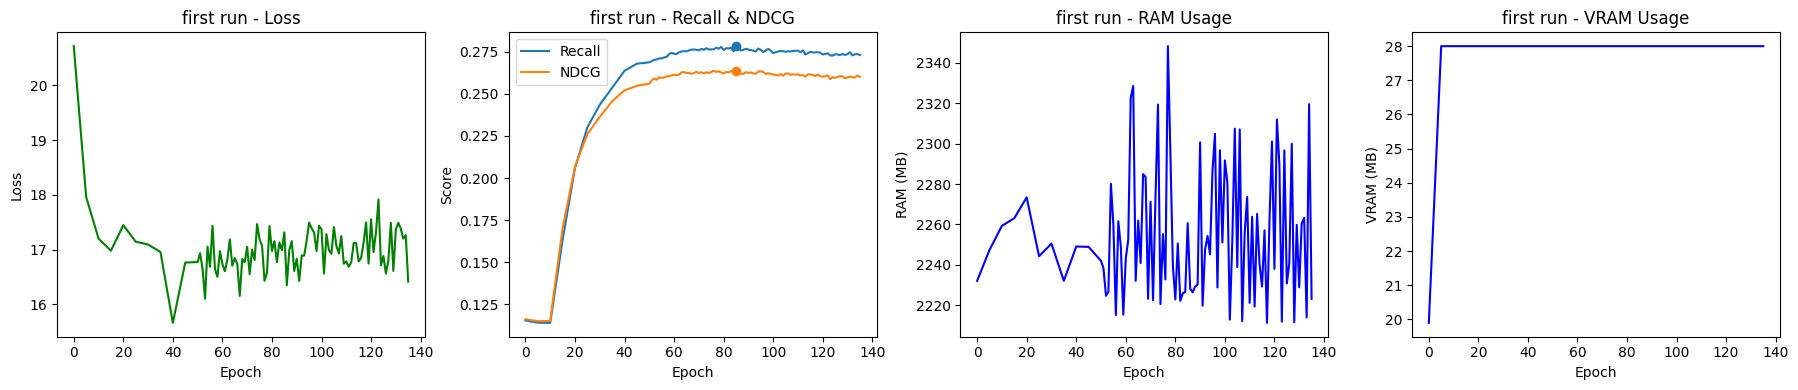

In [15]:
plot_metrics_from_log("movielen/first.txt")

Best Recall : 0.277300 @ epoch 77
Best NDCG   : 0.263600 @ epoch 72
Average System RAM : 2218.89 MB
Average System VRAM: 27.92 MB


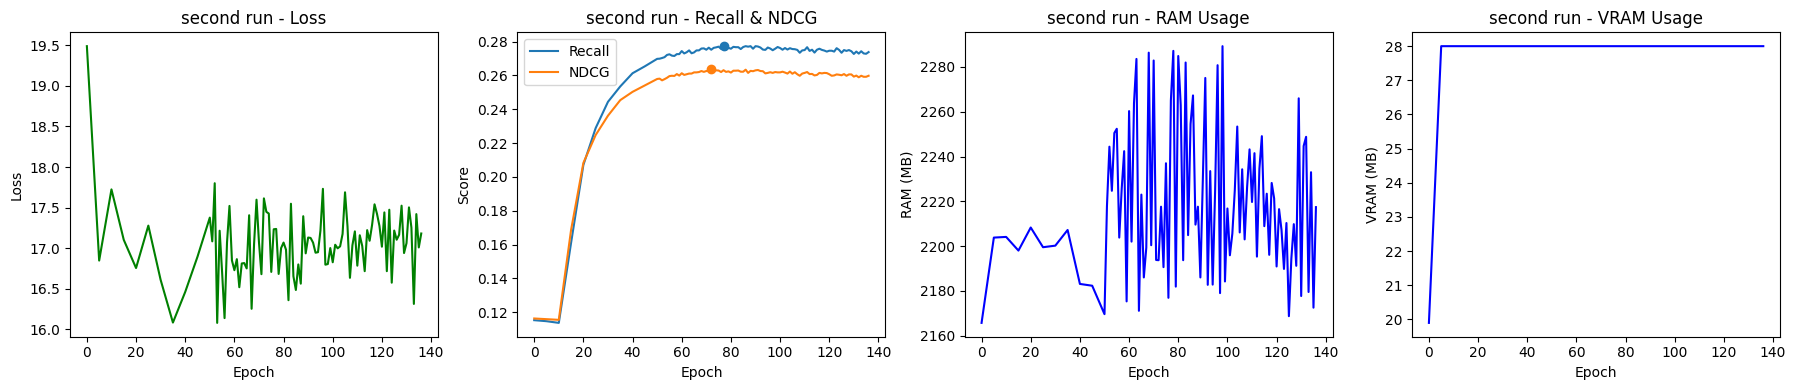

In [16]:
plot_metrics_from_log("movielen/second.txt")

Best Recall : 0.278200 @ epoch 88
Best NDCG   : 0.263400 @ epoch 75
Average System RAM : 2222.33 MB
Average System VRAM: 27.92 MB


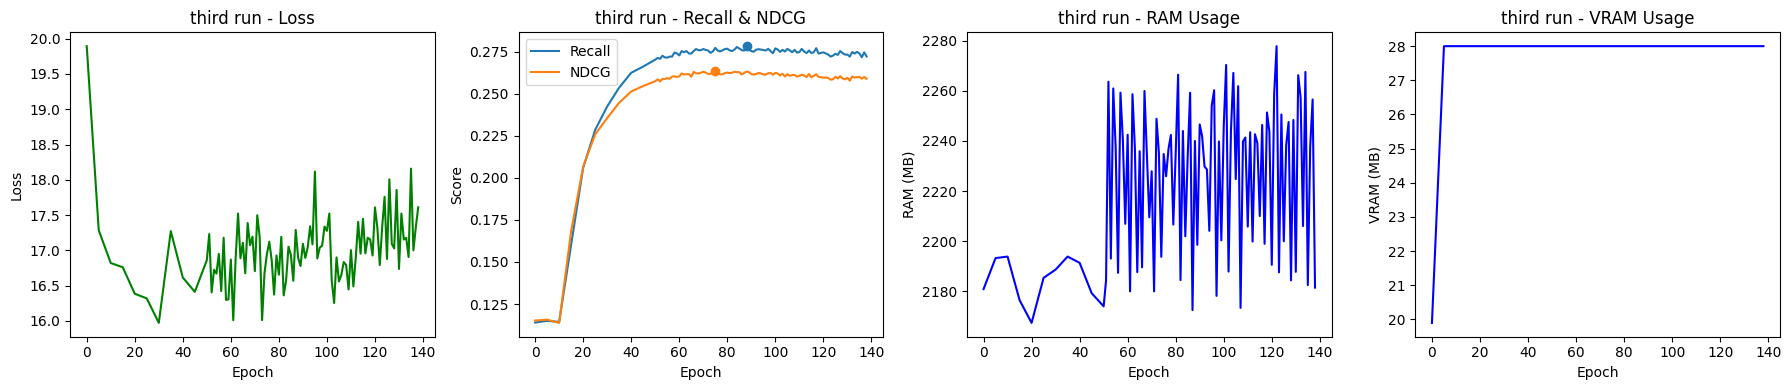

In [17]:
plot_metrics_from_log("movielen/third.txt")

**GitStar**

Best Recall : 0.053800 @ epoch 72
Best NDCG   : 0.022600 @ epoch 60
Average System RAM : 2584.68 MB
Average System VRAM: 31.63 MB


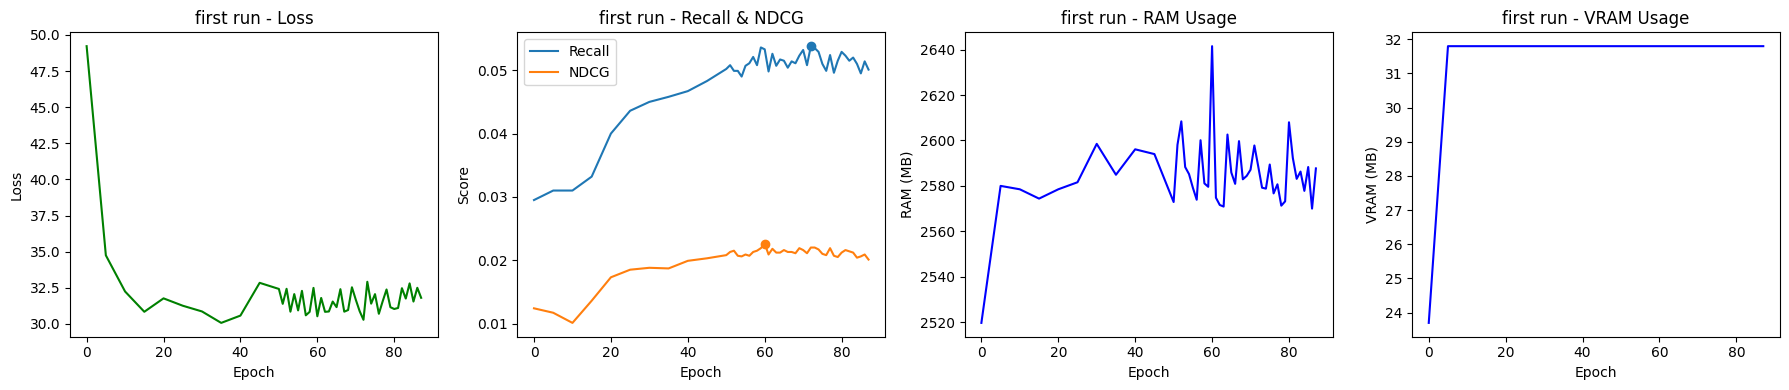

In [18]:
plot_metrics_from_log("gitstar/first.txt")

Best Recall : 0.053200 @ epoch 68
Best NDCG   : 0.021900 @ epoch 54
Average System RAM : 2585.74 MB
Average System VRAM: 31.62 MB


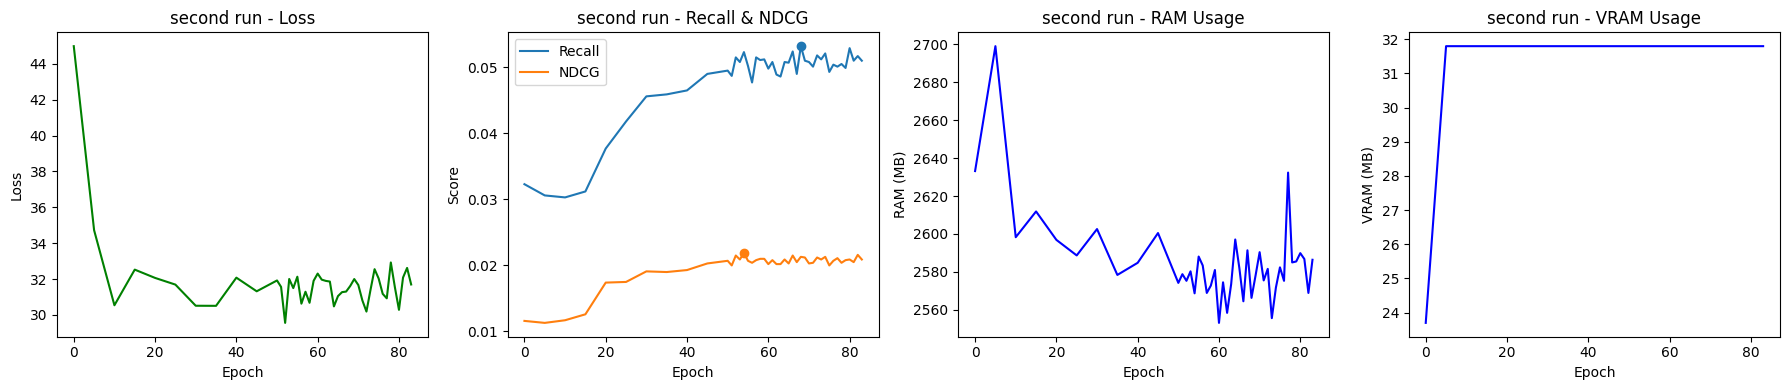

In [19]:
plot_metrics_from_log("gitstar/second.txt")

Best Recall : 0.054100 @ epoch 59
Best NDCG   : 0.022000 @ epoch 71
Average System RAM : 2578.84 MB
Average System VRAM: 31.57 MB


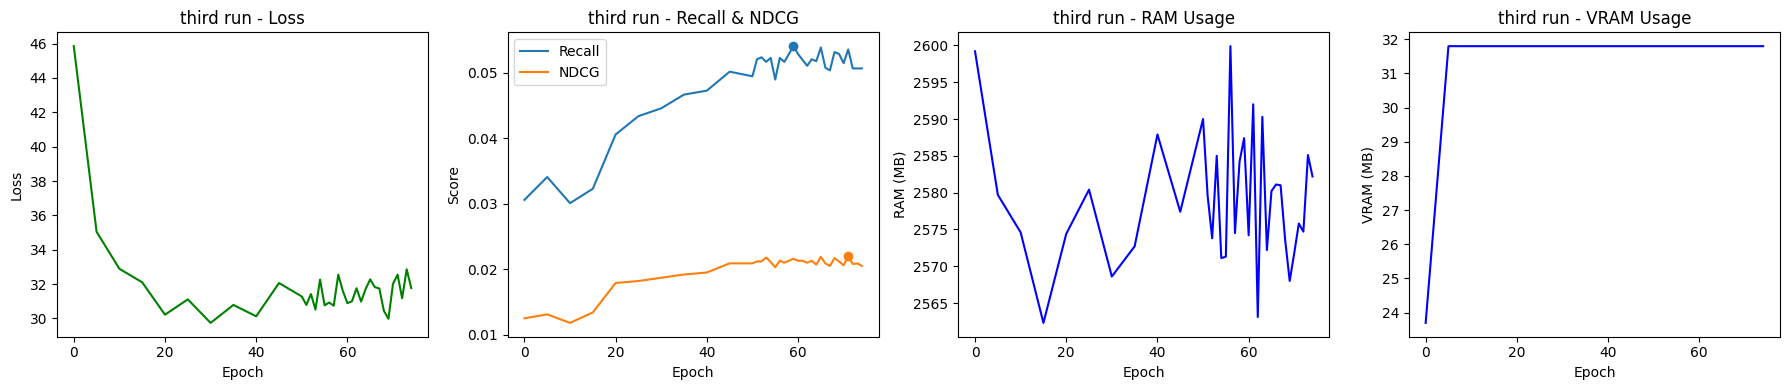

In [20]:
plot_metrics_from_log("gitstar/third.txt")